# Assignment 2 — Due 9:00 AM Sunday, 12 April 2026

**Name:** Rawan Mohamed **Student ID:** 202208263

### Submission

In your GitHub repo, under **`assign2`** subfolder:

1. **`tree.pdf`** — all work for Q1.  
2. **This notebook** — run all cells; outputs must be visible.

# Part 1 — Decision Trees (60 pts)

#### **Q1** [30 pts] **Approve Loan**
Build a decision tree **by hand** (paper or drawing tool). Put everything in `tree.pdf`.

- **[24 pts]** At **every** internal node: show the split rule you use, list the candidate splits, and compute the impurity measure (Gini **or** Entropy) for each candidate. Work must be shown step by step.
- **[3 pts]** Final tree diagram: clear structure; each leaf shows the predicted **Approve_Loan** class.
- **[3 pts]** Classify:
  - **A:** Age=Young, Income=High, Own_Home=No, Credit_History=Fair  
  - **B:** Age=Senior, Income=Low, Own_Home=Yes, Credit_History=Poor

| Age       | Income | Own_Home | Credit_History | Approve_Loan |
|-----------|--------|----------|----------------|--------------|
| Young     | High   | Yes      | Good           | Yes          |
| Young     | High   | No       | Good           | No           |
| Middle    | High   | Yes      | Good           | Yes          |
| Senior    | Medium | No       | Good           | Yes          |
| Senior    | Low    | Yes      | Fair           | Yes          |
| Senior    | Low    | No       | Fair           | No           |
| Middle    | Low    | Yes      | Fair           | Yes          |
| Young     | Medium | No       | Fair           | No           |
| Young     | Low    | Yes      | Good           | Yes          |
| Senior    | Medium | Yes      | Fair           | Yes          |
| Young     | Medium | Yes      | Poor           | No           |
| Middle    | Medium | No       | Good           | Yes          |
| Middle    | High   | Yes      | Poor           | Yes          |
| Senior    | Medium | No       | Poor           | No           |
| Young     | Low    | No       | Poor           | No           |

#### **Q2** [5 pts] Load `loan_dataset.csv` into a Pandas DataFrame and preprocess it. Prepare feature matrix and target so a `sklearn` decision tree can be trained.

- **[2 pts]** Encode the target variable using `LabelEncoder`.
- **[3 pts]** Encode the features using `OneHotEncoder` (set `sparse_output=False`).
- Display the first 5 rows of the preprocessed features and target.

In [57]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [18]:
# Your code here

loans = pd.read_csv('loan_dataset.csv')
label_encoder = LabelEncoder()
one_hot_encoder = OneHotEncoder(sparse_output=False)
loans["Approve_Loan"] = label_encoder.fit_transform(loans["Approve_Loan"])
# loans[["Age", "Income", "Own_Home", "Credit_History"]] = one_hot_encoder.fit_transform(loans[["Age", "Income", "Own_Home", "Credit_History"]]) => wrong because when we do one hot encoding, we get more columns than the original ones, so we can't assign it back to the original columns
encoded_features = one_hot_encoder.fit_transform(loans[["Age", "Income", "Own_Home", "Credit_History"]])
encoded_features_df = pd.DataFrame(encoded_features, columns=one_hot_encoder.get_feature_names_out(["Age", "Income", "Own_Home", "Credit_History"]))
loans = pd.concat([loans.drop(columns=["Age", "Income", "Own_Home", "Credit_History"]), encoded_features_df], axis=1)
x = loans.drop(columns=["Approve_Loan"])
y = loans["Approve_Loan"]
loans.head(5)


,Approve_Loan,Age_Middle,Age_Senior,Age_Young,Income_High,Income_Low,Income_Medium,Own_Home_No,Own_Home_Yes,Credit_History_Fair,Credit_History_Good,Credit_History_Poor
0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
2,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


#### **Q3** [4 pts] Train and evaluate a Decision Tree classifier.

- **[1 pt]** Split the data into 80% training / 20% testing (`random_state=42`).
- **[1 pt]** Train a Decision Tree Classifier with default parameters.
- **[1 pt]** Visualize the trained tree.
- **[1 pt]** Report the training accuracy and testing accuracy.

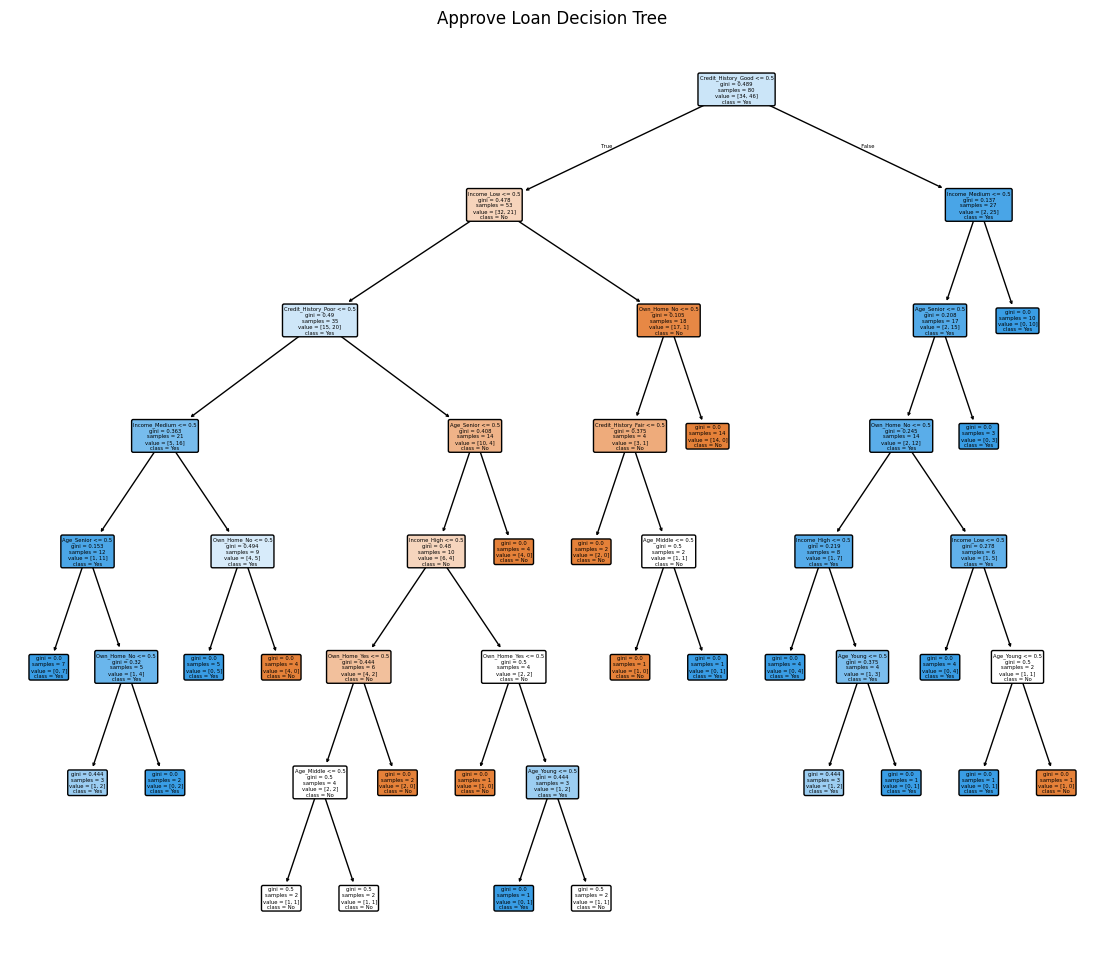

Train data accuracy (using .score method): 0.9375
Test data accuracy (using .score method): 0.9


In [30]:
# Your code here

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train, y_train)

plt.figure(figsize=(14, 12))
plot_tree(
    tree,
    feature_names=x.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True
)
plt.title("Approve Loan Decision Tree")
plt.show()

train_score = tree.score(x_train, y_train)
test_score = tree.score(x_test, y_test)

print("Train data accuracy (using .score method):", train_score)
print("Test data accuracy (using .score method):", test_score)



#### **Q4** [6 pts] **Test-set evaluation** (same model as Q3)

- **[1 pt]** Display Confusion matrix.
- **[1 pt]** Classification report (precision, recall, F1 per class).
- **[4 pts]** In a markdown below the code: Which class is harder to predict, and why? Is the model overfitting? Support your answers with the numbers you produced.

[[10  2]
 [ 0  8]]


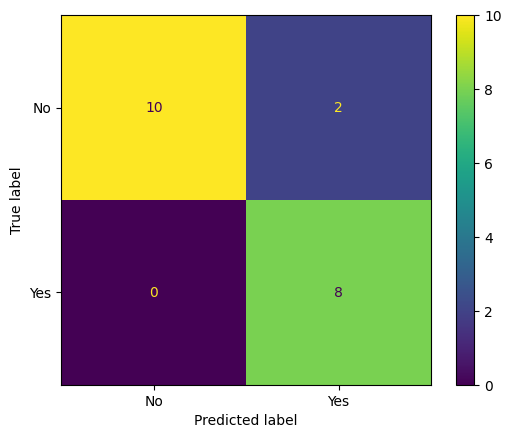

              precision    recall  f1-score   support

          No       1.00      0.83      0.91        12
         Yes       0.80      1.00      0.89         8

    accuracy                           0.90        20
   macro avg       0.90      0.92      0.90        20
weighted avg       0.92      0.90      0.90        20



In [21]:
# Your code here
y_true = y_test
y_pred = tree.predict(x_test)

cm = confusion_matrix(y_true, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.show()

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


*Which class is harder to predict, and why?*
- The No class is harder to predict as is it predicted a yes two times when it was actually no, while it never predicted a no for when it was a yes. This is further proven by the recall values for the No and Yes classes, yes has a 1 recall which means 0 have been misclassified, while No has 0.83 showing the 2 cases where it has been misclassified.

*Is the model overfitting?*
- the model is not overfitting as the difference between test accuracy and training accuracy is only about 4%, with the test accuracy being 90% while training accuracy about 94%. this shows that the model generalizes well to unseen data.

#### **Q5** [7 pts] Investigate the effect of tree depth on generalization.

- **[3 pts]** Train Decision Tree Classifier models with `max_depth` ∈ {2, 4, 6, 8, None}. Record the training and testing accuracy for each.
- **[2 pts]** Plot both curves (training & testing accuracy vs. max_depth) on the same graph with labels and legend.
- **[2 pts]** In markdown cell, which depth best balances bias and variance for this data? Explain using the curves.

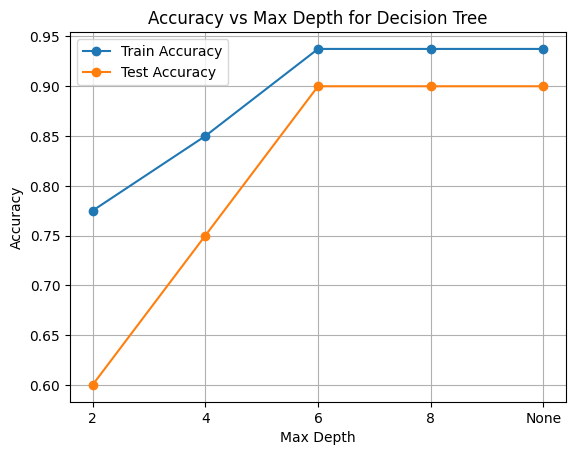

In [ ]:
# Your code here
max_depths = [2, 4, 6, 8]
train_scores = []
test_scores = []
none_train_score = train_score
non_test_score = test_score

for max_depth in max_depths:
    tree = DecisionTreeClassifier(random_state=42, max_depth=max_depth)
    tree.fit(x_train, y_train)
    train_score = tree.score(x_train, y_train)
    test_score = tree.score(x_test, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)

train_scores.append(none_train_score)
test_scores.append(non_test_score)

x_label = [2, 4, 6, 8, "None"]
plt.plot(x_label, train_scores, marker='o', label='Train Accuracy')
plt.plot(x_label, test_scores,  marker='o', label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Max Depth for Decision Tree')
plt.legend()
plt.grid()
plt.show()


The best Max_depth that balances bias and variance for this dataset seems to be 6. it yeilds an accuracy of 0.9, which is the same value we got for a no limit on the max_depth, but with a less complicated model. Meanwhile using any other value less than 6 shows high bias with a model that is not able to capture the pattern of the data.

#### **Q6** [8 pts] Train and compare a Random Forest model.

- **[4 pts]** Train a Random Forest Classifier. Experiment with `n_estimators` ∈ {50, 100, 200} and `max_features` ∈ {'sqrt', 'log2'}. Report the best combination based on test accuracy.
- **[2 pts]** Run 5-fold cross-validation on the best Random Forest. Report the fold accuracies, mean, and standard deviation.
- **[2 pts]** In markdpwn cell, compare the Random Forest to the best Decision Tree from Q5. Which generalizes better and why?

In [38]:
# Your code here
n_estimators = [50, 100, 200]
max_features = ['sqrt', 'log2']

best_acc = 0
best_params = []
best_rf = None

for n in [50, 100, 200]:
    for mf in ['sqrt', 'log2']:
        rf = RandomForestClassifier(n_estimators=n, max_features=mf, random_state=42)
        rf.fit(x_train, y_train)
        acc = rf.score(x_test, y_test)
        if acc > best_acc:
            best_acc = acc
            best_params = [n , mf] 
            best_rf = rf

print(f"best n_estimators: {best_params[0]}, best max_features: {best_params[1]} with test accuracy: {best_acc}")

scores = cross_val_score(best_rf, x_train, y_train, cv=5)
print(scores)

print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))



best n_estimators: 200, best max_features: sqrt with test accuracy: 0.8
[0.8125 0.75   0.8125 0.875  0.8125]
0.81 accuracy with a standard deviation of 0.04


The decision Tree from Q5 reported an accuracy of 0.9 which is better than the Random Forest accuracy of 0.8. Surprisengly, the decision tree here generalized better, this is becasue the dataset is very small and has clear and simple decision boundaries. Random forests work best when the decision boundries are noisy and the dataset is large where it has enough data to train the different trees. 

---

# Part 2 — kNN (40 pts)

Explore how different hyperparameters affect kNN classifier performance. You will:
1. Split data into training, validation, and testing sets.
2. Compare distance metrics: Euclidean (L2) vs. Manhattan (L1).
3. Perform a grid search over k and the distance metric to find optimal hyperparameters.
4. Evaluate the final tuned model on unseen data.

## Data (provided)

Run the next cells to build the **two circles** data (with extra noisy structure). Do not change the generation code.

In [77]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_circles

In [78]:
X, y = make_circles(n_samples=1000, noise=0.15, factor=0.5, random_state=37)

np.random.seed(21)
X_aug = X.tolist()
y_aug = y.tolist()

n_clusters = 15

for _ in range(n_clusters):
    idx = np.random.randint(0, len(X))
    base_point = X[idx]
    base_label = y[idx]

    new_label = 1 - base_label

    n_new_points = np.random.randint(5, 9)

    for _ in range(n_new_points):
        new_point = base_point + np.random.normal(scale=0.15, size=2)
        X_aug.append(new_point)
        y_aug.append(new_label)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("Original dataset size:", X.shape[0])
print("Augmented dataset size:", X_aug.shape[0])

Original dataset size: 1000
Augmented dataset size: 1100


## Visualize (run cell; figure provided)

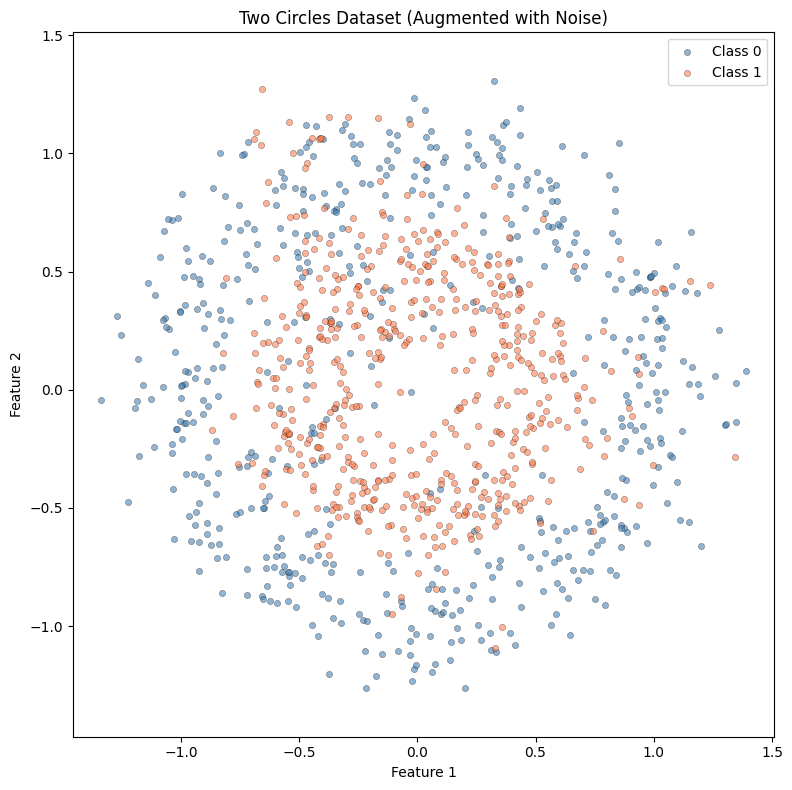

In [79]:
plt.figure(figsize=(8, 8))
plt.scatter(X_aug[y_aug == 0, 0], X_aug[y_aug == 0, 1],
            c='steelblue', label='Class 0', alpha=0.6, edgecolors='k', linewidths=0.3, s=20)
plt.scatter(X_aug[y_aug == 1, 0], X_aug[y_aug == 1, 1],
            c='coral', label='Class 1', alpha=0.6, edgecolors='k', linewidths=0.3, s=20)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Two Circles Dataset (Augmented with Noise)')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


## Step 1 [3 pts] — Split the Dataset
Split the data into **three** sets:
- **70%** Training
- **15%** Validation
- **15%** Testing

Use `random_state=42` for all splits. Print the shapes to verify.

In [80]:
# Your code here
x_train, x_test, y_train, y_test = train_test_split(X_aug, y_aug, test_size=0.15, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15/0.85, random_state=42)
print("Train set size:", x_train.shape[0])
print("Validation set size:", x_val.shape[0])
print("Test set size:", x_test.shape[0])

Train set size: 770
Validation set size: 165
Test set size: 165


## Step 2 [3 pts] — Baseline Euclidean

- **[2 pts]** Train a kNN classifier with `n_neighbors=5` and `p=2` (Euclidean).
- **[1 pt]** Predict on the **test** set. Print the accuracy.

In [81]:
# Your code here

knn = KNeighborsClassifier(n_neighbors=5, p=2)
knn.fit(x_train, y_train)
# print(knn.score(x_test, y_test))

y_pred = knn.predict(x_val)
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 84.85%


## Step 3 [3 pts] — kNN with k=5 and Manhattan Distance
- **[1 pt]** Train a kNN classifier with `n_neighbors=5` and `p=1` (Manhattan).
- **[1 pt]** Predict on the **test** set. Print the accuracy.
- **[1 pt]** In Markdown cell, compare results with step 2 and interpret.

In [82]:
# Your code here
knn = KNeighborsClassifier(n_neighbors=5, p=1)
knn.fit(x_train, y_train)
# print(knn.score(x_test, y_test))

y_pred = knn.predict(x_val)
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.06%


Using Manhattan distance resulted in a slightly better accuracy of 86% as opposed to approximately 85% for the euclidean distance. That could be because Manhattan is less sensitive to outliers, however, the difference is only about 1% which is not significant at all.

## Step 4 [10 pts] — Hyperparameter Tuning using Grid Search
- **[6 pts]** Perform a grid search over the **validation set** to find the best combination of:\
`k` ∈ {1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51} \
`p` ∈ {1, 2} &nbsp;(Manhattan vs. Euclidean) 

- **[2 pts]** Store the per-k accuracies for each distance metric (needed for Step 5).
- **[2 pts]** Identify and print the **best (k, p)** combination and its validation accuracy.


In [83]:
# Your code here
k = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51]
p = [1, 2]

accuracies = {1: [], 2: []}

best_acc = 0
best_k = None
best_p = None

for i in p:
    for j in k:
        knn = KNeighborsClassifier(n_neighbors=j, p=i)
        knn.fit(x_train, y_train)
        acc = knn.score(x_val, y_val)
        accuracies[i].append(acc)
        
        if acc > best_acc:
            best_acc = acc
            best_k = j
            best_p = i

print(f"Best k={best_k}, p={best_p}")
print(f"Validation accuracy: {best_acc * 100:.2f}%")


Best k=31, p=1
Validation accuracy: 89.09%


## Step 5 [9 pts] — Visualization of Accuracy vs. k
- **[4 pts]** Plot validation accuracy as a function of k with **two curves** on the same plot: \
One for Euclidean (`p=2`) \
One for Manhattan (`p=1`)
- **[1 pt]** Include a legend, axis labels, and a descriptive title.
- **[4 pts]** In a markdown cell below your plot, describe the bias-variance behavior you observe as k increases.

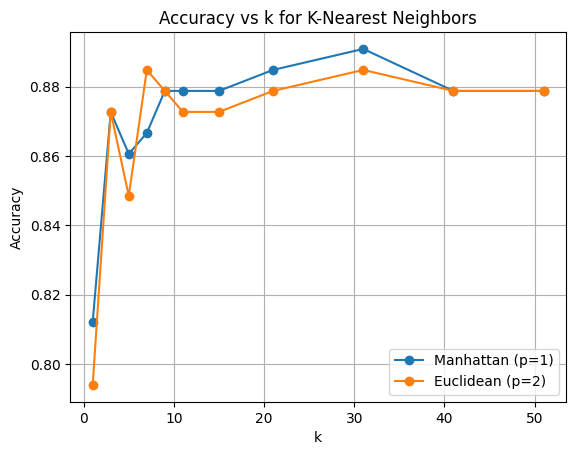

In [84]:
# Your code here
plt.plot(k, accuracies[1], marker='o', label='Manhattan (p=1)')
plt.plot(k, accuracies[2], marker='o', label='Euclidean (p=2)')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy vs k for K-Nearest Neighbors')
plt.legend()
plt.grid()
plt.show()

In the beginning, when is very small, variance is high and the model is highly affected by noise, this makes the accuracy of the model low. as k increases, noise points get "outvoted" by the majority and so the model becomes less affected by noise, variance decreases accuracy inceases. As k grows very large, high bias starts happening as too many neighbors are affecting the decision, introducing underfitting of the model and hence accuracy decreases again. the optimal value of k is that which balances bias and variance and hence yields the highest accuracy. Euclidean and Manhattan distances both show the same trend in the graph. However manhattan seems to handle noise a bit better at the optimum  value of k which happened to be 31 for this scenario.

## Step 6 [12 pts] — Final model

Using the best `(k, distance)` from Step 4.

- **[2 pts]** Retrain the model on the full training data (training + validation combined).
- **[2 pts]** Evaluate on the held-out test set and print the final test accuracy.
- **[2 pts]** Print the full classification report on the test set.
- **[2 pts]** In Markdown cell: which class is harder to predict, and what does that suggest about your chosen `k`?
- **[4 pts]** In Markdown cell: compare the final model accuracy vs. Steps 2 and 3. Did hyperparameter tuning improve performance? Explain Why or why not?

In [85]:
# Your code here

full_x_train = np.concatenate([x_train, x_val])
full_y_train = np.concatenate([y_train, y_val])

knn = KNeighborsClassifier(n_neighbors=best_k, p=best_p)
knn.fit(full_x_train, full_y_train)

final_acc = knn.score(x_test, y_test)   
y_pred_final = knn.predict(x_test)
print(f"Final test accuracy: {final_acc * 100:.2f}%")
print(classification_report(y_test, y_pred_final, target_names=["Class 0", "Class 1"]))




Final test accuracy: 88.48%
              precision    recall  f1-score   support

     Class 0       0.90      0.86      0.88        80
     Class 1       0.88      0.91      0.89        85

    accuracy                           0.88       165
   macro avg       0.89      0.88      0.88       165
weighted avg       0.89      0.88      0.88       165



*In Markdown cell: which class is harder to predict, and what does that suggest about your chosen `k`?*
- class zero seems to be harder to predict as it has a lower recall score of 0.86 than class 1 of 0.91. class 0 represented the outer circle in the dataset, which makes it more affected by noise as it is closer to the noise. The value of k=31 helps lower the effect of noise on the decision as it increases the number of votes to take the majority of, but that didn't fully cancel out the effect of noise on the outer ring (class 0). 

*In Markdown cell: compare the final model accuracy vs. Steps 2 and 3. Did hyperparameter tuning improve performance? Explain Why or why not?*
- Hyperparameter tuning definately improved the performance. in steps 2 and 3, we yielded an accuracy of about 85% (Euclidean) and 86% (Manhattan). After the tuning, we resulted in an accuracy of about 88.5%, which is an improvement over steps 2 and 3. we have come to this conclusion after having studied which k value is the best balance between variance and bias while also studying which distance metric handles noise best for this dataset. 
